In [13]:
import pandas as pd

In [14]:
sample = pd.read_csv("after_merge_1111.csv")


/var/folders/nw/cm9mnh314r948fx2f2wgq3xr0000gn/T/ipykernel_11167/1505962742.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  sample = pd.read_csv("after_merge_1111.csv")


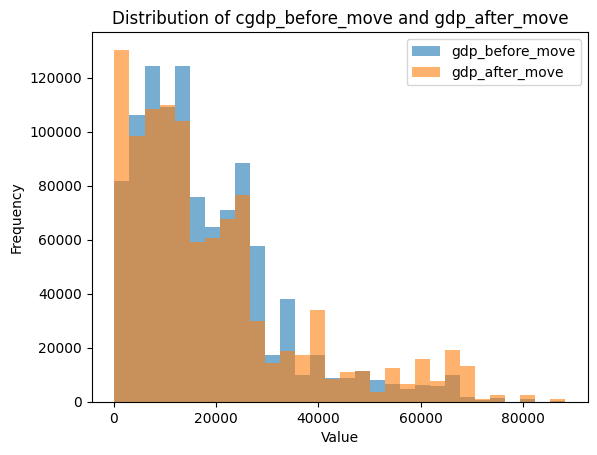

In [3]:
import matplotlib.pyplot as plt
plt.hist(sample['gdp_before_move'], bins=30, alpha=0.6, label='gdp_before_move')
plt.hist(sample['gdp_after_move'], bins=30, alpha=0.6, label='gdp_after_move')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of cgdp_before_move and gdp_after_move')
plt.legend()
plt.show()

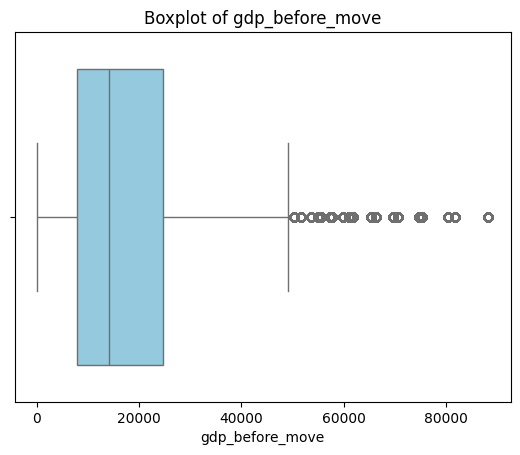

In [15]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# 假设你的DataFrame叫 df，变量名为 'income'
sns.boxplot(x=sample['gdp_before_move'], color='skyblue')

plt.title('Boxplot of gdp_before_move')
plt.xlabel('gdp_before_move')
plt.show()


In [16]:
import numpy as np

# 初始化默认值
sample['T0_b'] = 0
sample['T1_b'] = 0

# 生成条件
cond_T0 = sample['gdp_before_move'] > 40000
cond_T1 = (sample['gdp_before_move'] > 30000) & (sample['gdp_before_move'] <= 40000)

# 应用条件
sample.loc[cond_T0, 'T0_b'] = 1
sample.loc[cond_T1, 'T1_b'] = 1


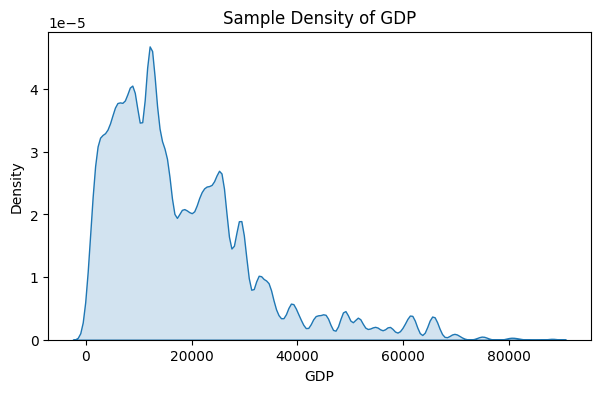

In [19]:
# 初始化默认值
sample['T0_a'] = 0
sample['T1_a'] = 0

# 生成条件
cond_T0 = sample['gdp_before_move'] > 40000
cond_T1 = (sample['gdp_before_move'] > 30000) & (sample['gdp_before_move'] <= 40000)

# 应用条件
sample.loc[cond_T0, 'T0_a'] = 1
sample.loc[cond_T1, 'T1_a'] = 1
import seaborn as sns
fig, ax1 = plt.subplots(figsize=(7,4))
sns.kdeplot(sample['gdp_before_move'], fill=True, alpha=0.2, ax=ax1)
ax1.set_xlabel('GDP')
ax1.set_ylabel('Density')
ax1.set_title('Sample Density of GDP')
plt.show()


In [ ]:
# === IPW方法 ====
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ==== Step 0: 数据准备 ====
# 列名列表（不要把 DataFrame 当作列索引）
cols = ['high_school','junior_college','bachelor','rural', 'income_total_m']

# 只对这些列填 0（先数值化，无法转的设为 NaN 再填 0）
sample[cols] = sample[cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# 目标与处理
Y = sample['is_beijing'].astype(int).to_numpy()   # 是否迁移（0/1）
T = sample['T1_b'].astype(int).to_numpy()         # 处理（0/1）

# 设计矩阵
X_mat = sample[cols].to_numpy()

# ==== Step 1: 倾向得分模型 ====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mat)

# T 必须包含 0 和 1 两类，否则逻辑回归会报错
if len(np.unique(T)) < 2:
    raise ValueError("T 仅有一个取值（全是0或全是1），无法拟合倾向得分模型。")

logit = LogisticRegression(max_iter=1000)
logit.fit(X_scaled, T)
propensity = logit.predict_proba(X_scaled)[:, 1]  # P(T=1|X)

# ==== Step 2: 计算逆倾向加权（加上极端概率裁剪避免除零） ====
eps = 1e-6
ps = np.clip(propensity, eps, 1 - eps)

sample = sample.copy()  # 避免链式赋值告警
sample['pscore'] = ps
sample['weight'] = np.where(T == 1, 1/ps, 1/(1 - ps))

# ==== Step 3: 估计 ATE （IPW 的加权均值差）====
mask1 = (T == 1)
mask0 = (T == 0)

ate_treated  = (sample.loc[mask1, 'weight'] * Y[mask1]).sum() / sample.loc[mask1, 'weight'].sum()
ate_control  = (sample.loc[mask0, 'weight'] * Y[mask0]).sum() / sample.loc[mask0, 'weight'].sum()
ATE_IPW = ate_treated - ate_control

print(f"Estimated ATE (Inverse Propensity Weighting): {ATE_IPW:.4f}")

# ==== Step 4: 倾向得分分布可视化 ====
plt.hist(sample.loc[mask1, 'pscore'], bins=30, alpha=0.5, label='Treated')
plt.hist(sample.loc[mask0, 'pscore'], bins=30, alpha=0.5, label='Control')
plt.xlabel('Propensity Score')
plt.ylabel('Count')
plt.legend()
plt.title('Propensity Score Distribution by Treatment Group')
plt.show()


In [6]:
sample['T01_b'] = ((sample['T0_b'] == 1) | (sample['T1_b'] == 1)).astype(int)
sample['T01_a'] = ((sample['T0_a'] == 1) | (sample['T1_a'] == 1)).astype(int)
sample['T23_b'] = ((sample['T0_b'] != 1) & (sample['T1_b'] != 1)).astype(int)
sample['T23_a'] = ((sample['T0_a'] != 1) & (sample['T1_a'] != 1)).astype(int)


In [7]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

#==== 此版本对Imbalanced Data进行改进 =======

# ===================== 可配置区 =====================
Y_col = 'is_beijing'                            # 稀有事件：是否迁往北京/上海
T_col = 'T23_b'                                  # 处理变量（0/1）
X_cols = ['high_school','junior_college','bachelor','rural','income_total_m',"hs_residence",'male','age',"T01_a"]  # 协变量
eps = 1e-5                                      # 倾向得分/概率裁剪，防止除零和权重爆炸
# ===================================================

# -------- 0. 数据清理：数值化 + 缺失填补 --------
df = sample.copy()
df[X_cols] = df[X_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

Y = df[Y_col].astype(int).values
T = df[T_col].astype(int).values
X = df[X_cols].values

# -------- 1. 标准化特征（提升稳定性） --------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# -------- 2. 倾向得分模型 e(X) = P(T=1|X) --------
# 稀有/不平衡时使用 class_weight='balanced'
# 为了更好的概率校准，再套上 CalibratedClassifierCV（等价 Platt scaling / isotonic）
base_ps = LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l2', solver='liblinear')
ps_model = CalibratedClassifierCV(base_ps, method='isotonic', cv=3)  # 小数据可用 'sigmoid'
ps_model.fit(X_std, T)
e_hat = ps_model.predict_proba(X_std)[:, 1]
e_hat = np.clip(e_hat, eps, 1 - eps)

# -------- 3. 结果模型 m1(X)=E[Y|T=1,X], m0(X)=E[Y|T=0,X] --------
# 在T=1子样本上拟合m1；在T=0子样本上拟合m0
# Y为稀有事件，用 class_weight='balanced' 并做概率校准
def fit_prob_model(X_fit, y_fit):
    base = LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l2', solver='liblinear')
    model = CalibratedClassifierCV(base, method='isotonic', cv=3)
    model.fit(X_fit, y_fit)
    return model

m1_model = fit_prob_model(X_std[T==1], Y[T==1])   # treated outcome model
m0_model = fit_prob_model(X_std[T==0], Y[T==0])   # control outcome model

m1_hat = m1_model.predict_proba(X_std)[:, 1]
m0_hat = m0_model.predict_proba(X_std)[:, 1]

m1_hat = np.clip(m1_hat, eps, 1 - eps)
m0_hat = np.clip(m0_hat, eps, 1 - eps)

# -------- 4. AIPW（双重稳健）ATE 估计 --------
#  ψ_i = T_i*(Y_i - m1)/e - (1-T_i)*(Y_i - m0)/(1-e) + (m1 - m0)
psi = T * (Y - m1_hat) / e_hat - (1 - T) * (Y - m0_hat) / (1 - e_hat) + (m1_hat - m0_hat)
ATE_AIPW = psi.mean()

print(f"AIPW ATE (double robust): {ATE_AIPW:.6f}")

# -------- 5. 诊断：重叠性、极端权重、有效样本占比 --------
w_ipw = np.where(T==1, 1/e_hat, 1/(1-e_hat))
print("Diagnostics:")
print(f"  Treated share: {T.mean():.4f}")
print(f"  Propensity e(X)  min/1%/median/99%/max: "
      f"{e_hat.min():.5f} / {np.quantile(e_hat,0.01):.5f} / {np.median(e_hat):.5f} / "
      f"{np.quantile(e_hat,0.99):.5f} / {e_hat.max():.5f}")
print(f"  IPW weight     mean/std/max: {w_ipw.mean():.4f} / {w_ipw.std():.4f} / {w_ipw.max():.1f}")


AIPW ATE (double robust): -0.007119
Diagnostics:
  Treated share: 0.8530
  Propensity e(X)  min/1%/median/99%/max: 0.00001 / 0.00001 / 0.99999 / 0.99999 / 0.99999
  IPW weight     mean/std/max: 1.0001 / 0.0007 / 1.5


In [ ]:
# 经验分箱
q = pd.qcut(df['T_proc'], q=10, duplicates='drop')
bin_mean_T = df.groupby(q)['T_proc'].mean()
bin_mean_Y = df.groupby(q)[Y_col].mean()

# 模型 μ(t) 对比（用每个箱的 T 均值预测 μ）
mu_bin = predict_mu_over_grid(bin_mean_T.values)

print(pd.DataFrame({
    'T_bin_mean': bin_mean_T.values,
    'empirical_rate': bin_mean_Y.values,
    'model_mu': mu_bin
}))

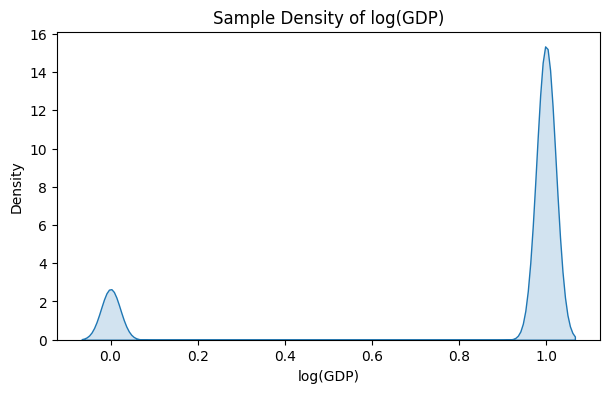

In [8]:
import seaborn as sns
fig, ax1 = plt.subplots(figsize=(7,4))
sns.kdeplot(T, fill=True, alpha=0.2, ax=ax1)
ax1.set_xlabel('log(GDP)')
ax1.set_ylabel('Density')
ax1.set_title('Sample Density of log(GDP)')
plt.show()

关键点（DRF 与边际效应；log尺度 & 1% 变动）：
  t≈Q10:  mu(t)=0.0214,  dmu/dlogGDP=0.001960,  (Δ1%)≈0.000020
  t≈Q50:  mu(t)=0.0249,  dmu/dlogGDP=0.000008,  (Δ1%)≈0.000000
  t≈Q90:  mu(t)=0.0229,  dmu/dlogGDP=-0.003244,  (Δ1%)≈-0.000032
Parametric Bootstrap 进行中（T|X 正态 + 二阶段 logit 生成）...
Parametric Bootstrap 完成。


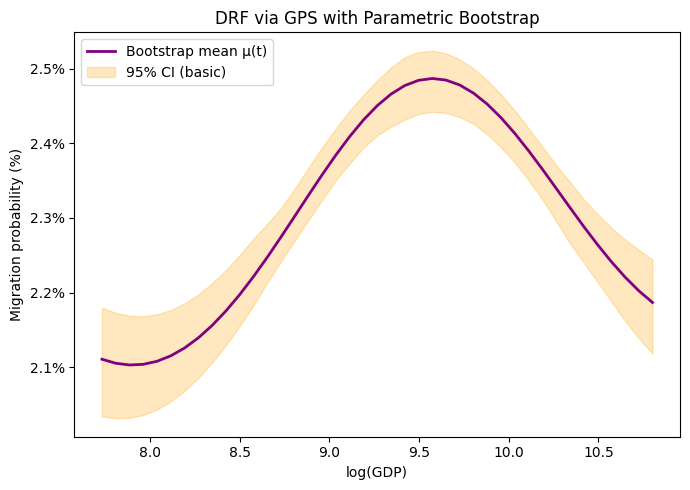

In [23]:
# ============================================
# 连续处理：log(GDP) 的剂量-反应函数 & 边际处理效应（GPS 方法）
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from scipy.stats import norm


# ======= 配置区（按需修改）========
df = sample.copy()                       # <- 你的数据框
T_raw_col = 'gdp_before_move'            # 连续处理（原始 GDP）
USE_LOG_T = True                         # ★ 使用 log(GDP) 作为处理 这里使用GDP log值
df['is_migrated_BJSH'] = ((df['is_beijing'] == 1) | (df['is_shanghai'] == 1)).astype(int)
Y_col = 'is_beijing'       # 结果（0/1）
X_cols = ['high_school','junior_college','bachelor','rural','income_total_m']  # 协变量

POLY_DEGREE = 2                          # 第二阶段多项式阶数：2 或 3 常用
GRID_Q_LOW, GRID_Q_HIGH = 0.05, 0.95     # 在 T 的 5%~95% 分位区间上评估
N_GRID = 41                              # t 网格点数量
BOOTSTRAP_B = 100                        # bootstrap 次数（先小后大）
RANDOM_STATE = 42                        # 随机数种子
# =================================

# ---- 预处理：构造 T（log 变换），清理数据 ----
df = df.copy()
# 仅对正的 GDP 取对数；若存在 0/负值，可选择剔除或加常数后取对数（谨慎）
df = df[pd.to_numeric(df[T_raw_col], errors='coerce') > 0].copy()
df[T_raw_col] = pd.to_numeric(df[T_raw_col], errors='coerce')

if USE_LOG_T:
    df = df.assign(T_proc=np.log(df[T_raw_col]))
    T_label = 'log(GDP)'
else:
    df = df.assign(T_proc=df[T_raw_col].astype(float))
    T_label = 'GDP'

keep_cols = [Y_col, 'T_proc'] + X_cols
df = df.dropna(subset=keep_cols).copy()

# 数值化协变量并缺失填 0（稳妥）
for c in X_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

Y = df[Y_col].astype(int).values
T = df['T_proc'].astype(float).values
X = df[X_cols].values

# ---- 标准化 X，用于第一阶段线性回归 ----
scaler_X = StandardScaler()
X_std = scaler_X.fit_transform(X)

# ---- 第一阶段：T|X ~ Normal(mu(X), sigma^2) ----
mu_model = LinearRegression()
mu_model.fit(X_std, T)
mu_hat = mu_model.predict(X_std)
sigma_hat = np.std(T - mu_hat, ddof=X_std.shape[1] + 1)
sigma_hat = max(sigma_hat, 1e-6)  # 防止极小 sigma

# ---- GPS：r(T|X)=phi((T - mu)/sigma)/sigma ----
gps = norm.pdf((T - mu_hat) / sigma_hat) / sigma_hat
gps = np.clip(gps, 1e-12, None)
df['gps'] = gps

# ---- 第二阶段：Y ~ poly(T, gps)（含交互），用逻辑回归拟合 E[Y|T,gps] ----
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=True)
Z = poly.fit_transform(np.c_[T, gps])

outcome_model = LogisticRegression(max_iter=5000)
outcome_model.fit(Z, Y)

# ---- 构造函数：给定 t，计算 mu(t) = E_i[ m(t, r(t,X_i)) ] ----
def compute_gps_at_t(t, mu_x, sigma):
    r = norm.pdf((t - mu_x) / sigma) / sigma
    return np.clip(r, 1e-12, None)

def predict_mu_over_grid(t_grid):
    mu_of_t = []
    mu_x_all = mu_model.predict(X_std)  # mu(X_i) 只拟合一次
    for t in t_grid:
        gps_t = compute_gps_at_t(t, mu_x_all, sigma_hat)
        Z_t = poly.transform(np.c_[np.full_like(gps_t, t, dtype=float), gps_t])
        m_ti = outcome_model.predict_proba(Z_t)[:, 1]
        mu_of_t.append(m_ti.mean())
    return np.array(mu_of_t)

def numerical_derivative(x, y):
    dydx = np.empty_like(y)
    dydx[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])  # 中心差分
    dydx[0]  = (y[1] - y[0]) / (x[1] - x[0])          # 前向
    dydx[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])      # 后向
    return dydx

# ---- t 网格 & 主估计（t 现在是 log(GDP) 尺度）----
t_low, t_high = np.quantile(T, GRID_Q_LOW), np.quantile(T, GRID_Q_HIGH)
t_grid = np.linspace(t_low, t_high, N_GRID)

mu_hat_grid = predict_mu_over_grid(t_grid)
marginal_effect_log = numerical_derivative(t_grid, mu_hat_grid)   # d mu / d log(GDP)
marginal_effect_pct = 0.01 * marginal_effect_log                  # 1% GDP 变化的边际效应

print("关键点（DRF 与边际效应；log尺度 & 1% 变动）：")
for p in [0.1, 0.5, 0.9]:
    tp = np.quantile(T, p)
    idx = np.argmin(np.abs(t_grid - tp))
    print(f"  t≈Q{int(p*100)}:  mu(t)={mu_hat_grid[idx]:.4f},  "
          f"dmu/dlogGDP={marginal_effect_log[idx]:.6f},  "
          f"(Δ1%)≈{marginal_effect_pct[idx]:.6f}")

# ========= Parametric Bootstrap for DRF (pointwise CIs) =========
from numpy.random import default_rng
rng = default_rng(RANDOM_STATE)

def simulate_one_bootstrap(mu_model, sigma_hat, outcome_model, poly, X_std, X, t_grid):
    """
    用已拟合的一/二阶段模型参数，模拟一个自助样本 (T_b, Y_b)，
    然后在该样本上重跑整条管线，返回该样本的 mu_b(t)。
    """
    n = X.shape[0]

    # —— 1) 按 T|X 的正态工作模型模拟 T_b
    mu_x = mu_model.predict(X_std)
    T_b = rng.normal(loc=mu_x, scale=sigma_hat, size=n)

    # —— 2) 根据二阶段 outcome_model 计算 p_b 并模拟 Y_b
    gps_b = norm.pdf((T_b - mu_x) / sigma_hat) / sigma_hat
    gps_b = np.clip(gps_b, 1e-12, None)
    Z_b_sim = poly.transform(np.c_[T_b, gps_b])
    p_b = outcome_model.predict_proba(Z_b_sim)[:, 1]
    Y_b = rng.binomial(1, np.clip(p_b, 1e-8, 1-1e-8), size=n).astype(int)

    # —— 3) 在 (Y_b, T_b, X) 上重拟合一/二阶段
    mu_m = LinearRegression().fit(X_std, T_b)
    mu_hat_b = mu_m.predict(X_std)
    sigma_b = np.std(T_b - mu_hat_b, ddof=X_std.shape[1] + 1)
    sigma_b = max(sigma_b, 1e-6)

    gps_refit = norm.pdf((T_b - mu_hat_b) / sigma_b) / sigma_b
    gps_refit = np.clip(gps_refit, 1e-12, None)

    Z_refit = poly.fit_transform(np.c_[T_b, gps_refit])
    out_m = LogisticRegression(max_iter=5000)
    out_m.fit(Z_refit, Y_b)

    # —— 4) 计算该样本上的 mu_b(t)
    mu_x_all_b = mu_m.predict(X_std)
    mu_vec = []
    for t in t_grid:
        gps_t_b = norm.pdf((t - mu_x_all_b) / sigma_b) / sigma_b
        gps_t_b = np.clip(gps_t_b, 1e-12, None)
        Z_t_b = poly.transform(np.c_[np.full_like(gps_t_b, t, dtype=float), gps_t_b])
        m_ti_b = out_m.predict_proba(Z_t_b)[:, 1]
        mu_vec.append(m_ti_b.mean())
    return np.array(mu_vec)

def parametric_bootstrap_drf(n_boot=BOOTSTRAP_B):
    mu_boot = np.zeros((n_boot, len(t_grid)))
    for b in range(n_boot):
        mu_boot[b] = simulate_one_bootstrap(mu_model, sigma_hat, outcome_model, poly, X_std, X, t_grid)
    return mu_boot

print("Parametric Bootstrap 进行中（T|X 正态 + 二阶段 logit 生成）...")
mu_boot = parametric_bootstrap_drf(n_boot=BOOTSTRAP_B)
print("Parametric Bootstrap 完成。")

# —— 点位置信区间：percentile 与 basic（推荐 basic）
alpha = 0.05
q_lo = np.quantile(mu_boot, alpha/2, axis=0)
q_hi = np.quantile(mu_boot, 1 - alpha/2, axis=0)

# 百分位区间
mu_lb_pct, mu_ub_pct = q_lo, q_hi
# basic 区间（对偏差有修正）
mu_lb_basic = 2*mu_hat_grid - q_hi
mu_ub_basic = 2*mu_hat_grid - q_lo

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# —— 小工具：把概率转成百分数
to_pct = lambda a: 100.0 * a

# 代表性曲线：平均 或 中位数（二选一，默认平均）
mu_boot_mean = mu_boot.mean(axis=0)          # 平均曲线
# mu_boot_med = np.median(mu_boot, axis=0)   # 或中位数曲线

plt.figure(figsize=(7,5))

# 只画一条 bootstrap 代表曲线（百分数）
plt.plot(t_grid, to_pct(mu_boot_mean), color='purple', linewidth=2,
         label='Bootstrap mean μ(t)')

# 如需对比你的点估计 μ(t)，可保留下一行（已转百分数）
# plt.plot(t_grid, to_pct(mu_hat_grid), color='blue', linestyle='--', linewidth=1.6,
#          label='Point estimate μ(t)')

# 置信带（basic 或 percentile 选其一；这里用 basic，并转百分数）
plt.fill_between(t_grid, to_pct(mu_lb_basic), to_pct(mu_ub_basic),
                 color='orange', alpha=0.25, label='95% CI (basic)')
# 若想改用百分位区间，请注释上一段、启用下一段：
# plt.fill_between(t_grid, to_pct(mu_lb_pct), to_pct(mu_ub_pct),
#                  color='skyblue', alpha=0.20, label='95% CI (percentile)')

plt.xlabel(T_label)  # 仍为 'log(GDP)'
plt.ylabel('Migration probability (%)')  # 更直观的纵轴名称
plt.title('DRF via GPS with Parametric Bootstrap')

# （可选）让刻度带上百分号，如果你没把数据乘以100，也可只用这个格式化器
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:.1f}%'))

plt.legend()
plt.tight_layout()
plt.show()

 

In [27]:
df['is_shanghai'] = pd.to_numeric(df['is_shanghai'], errors='coerce').fillna(0).astype(int)
print(df['is_shanghai'].value_counts(dropna=False))


is_shanghai
0    1024487
1      33800
Name: count, dtype: int64


In [28]:
# 1) 基准概率
print('Shanghai base rate =', df['is_shanghai'].mean())

# 2) 尾部重叠（样本量）查看
for q in [0.05, 0.95]:
    t_q = np.quantile(df['T_proc'], q)
    near = np.abs(df['T_proc'] - t_q) < 0.05
    print(f'Near Q{int(q*100)} count:', near.sum(), ' | SH migrants:', (near & (df['is_shanghai']==1)).sum())

# 3) 结果模型的校准粗检（Brier）
from sklearn.metrics import brier_score_loss
p_hat = outcome_model.predict_proba(Z)[:,1]
print('Brier score (lower better)=', brier_score_loss(Y, p_hat))


Shanghai base rate = 0.031938406122346774
Near Q5 count: 10165  | SH migrants: 442
Near Q95 count: 19225  | SH migrants: 617
Brier score (lower better)= 0.030857307189737303


关键点（DRF 与边际效应；log尺度 & 1% 变动）：
  t≈Q10:  mu(t)=0.0403,  dmu/dlogGDP=0.021541,  (Δ1%)≈0.000215
  t≈Q50:  mu(t)=0.0293,  dmu/dlogGDP=-0.010578,  (Δ1%)≈-0.000106
  t≈Q90:  mu(t)=0.0309,  dmu/dlogGDP=0.009147,  (Δ1%)≈0.000091
Parametric Bootstrap 进行中（T|X 正态 + 二阶段 logit 生成）...
Parametric Bootstrap 完成。


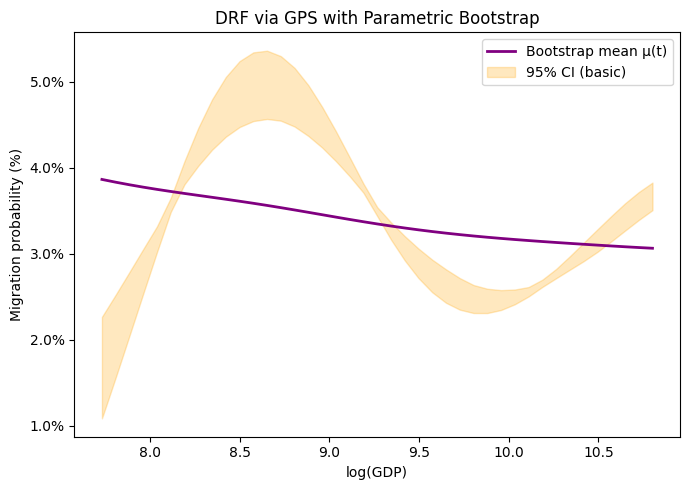

In [24]:
# ============================================
# 连续处理：log(GDP) 的剂量-反应函数 & 边际处理效应（GPS 方法）
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from scipy.stats import norm


# ======= 配置区（按需修改）========
df = sample.copy()                       # <- 你的数据框
T_raw_col = 'gdp_before_move'            # 连续处理（原始 GDP）
USE_LOG_T = True                         # ★ 使用 log(GDP) 作为处理 这里使用GDP log值
df['is_migrated_BJSH'] = ((df['is_beijing'] == 1) | (df['is_shanghai'] == 1)).astype(int)
Y_col = 'is_shanghai'       # 结果（0/1）
X_cols = ['high_school','junior_college','bachelor','rural','income_total_m']  # 协变量

POLY_DEGREE = 2                          # 第二阶段多项式阶数：2 或 3 常用
GRID_Q_LOW, GRID_Q_HIGH = 0.05, 0.95     # 在 T 的 5%~95% 分位区间上评估
N_GRID = 41                              # t 网格点数量
BOOTSTRAP_B = 100                        # bootstrap 次数（先小后大）
RANDOM_STATE = 42                        # 随机数种子
# =================================

# ---- 预处理：构造 T（log 变换），清理数据 ----
df = df.copy()
# 仅对正的 GDP 取对数；若存在 0/负值，可选择剔除或加常数后取对数（谨慎）
df = df[pd.to_numeric(df[T_raw_col], errors='coerce') > 0].copy()
df[T_raw_col] = pd.to_numeric(df[T_raw_col], errors='coerce')

if USE_LOG_T:
    df = df.assign(T_proc=np.log(df[T_raw_col]))
    T_label = 'log(GDP)'
else:
    df = df.assign(T_proc=df[T_raw_col].astype(float))
    T_label = 'GDP'

keep_cols = [Y_col, 'T_proc'] + X_cols
df = df.dropna(subset=keep_cols).copy()

# 数值化协变量并缺失填 0（稳妥）
for c in X_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

Y = df[Y_col].astype(int).values
T = df['T_proc'].astype(float).values
X = df[X_cols].values

# ---- 标准化 X，用于第一阶段线性回归 ----
scaler_X = StandardScaler()
X_std = scaler_X.fit_transform(X)

# ---- 第一阶段：T|X ~ Normal(mu(X), sigma^2) ----
mu_model = LinearRegression()
mu_model.fit(X_std, T)
mu_hat = mu_model.predict(X_std)
sigma_hat = np.std(T - mu_hat, ddof=X_std.shape[1] + 1)
sigma_hat = max(sigma_hat, 1e-6)  # 防止极小 sigma

# ---- GPS：r(T|X)=phi((T - mu)/sigma)/sigma ----
gps = norm.pdf((T - mu_hat) / sigma_hat) / sigma_hat
gps = np.clip(gps, 1e-12, None)
df['gps'] = gps

# ---- 第二阶段：Y ~ poly(T, gps)（含交互），用逻辑回归拟合 E[Y|T,gps] ----
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=True)
Z = poly.fit_transform(np.c_[T, gps])

outcome_model = LogisticRegression(max_iter=5000)
outcome_model.fit(Z, Y)

# ---- 构造函数：给定 t，计算 mu(t) = E_i[ m(t, r(t,X_i)) ] ----
def compute_gps_at_t(t, mu_x, sigma):
    r = norm.pdf((t - mu_x) / sigma) / sigma
    return np.clip(r, 1e-12, None)

def predict_mu_over_grid(t_grid):
    mu_of_t = []
    mu_x_all = mu_model.predict(X_std)  # mu(X_i) 只拟合一次
    for t in t_grid:
        gps_t = compute_gps_at_t(t, mu_x_all, sigma_hat)
        Z_t = poly.transform(np.c_[np.full_like(gps_t, t, dtype=float), gps_t])
        m_ti = outcome_model.predict_proba(Z_t)[:, 1]
        mu_of_t.append(m_ti.mean())
    return np.array(mu_of_t)

def numerical_derivative(x, y):
    dydx = np.empty_like(y)
    dydx[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])  # 中心差分
    dydx[0]  = (y[1] - y[0]) / (x[1] - x[0])          # 前向
    dydx[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])      # 后向
    return dydx

# ---- t 网格 & 主估计（t 现在是 log(GDP) 尺度）----
t_low, t_high = np.quantile(T, GRID_Q_LOW), np.quantile(T, GRID_Q_HIGH)
t_grid = np.linspace(t_low, t_high, N_GRID)

mu_hat_grid = predict_mu_over_grid(t_grid)
marginal_effect_log = numerical_derivative(t_grid, mu_hat_grid)   # d mu / d log(GDP)
marginal_effect_pct = 0.01 * marginal_effect_log                  # 1% GDP 变化的边际效应

print("关键点（DRF 与边际效应；log尺度 & 1% 变动）：")
for p in [0.1, 0.5, 0.9]:
    tp = np.quantile(T, p)
    idx = np.argmin(np.abs(t_grid - tp))
    print(f"  t≈Q{int(p*100)}:  mu(t)={mu_hat_grid[idx]:.4f},  "
          f"dmu/dlogGDP={marginal_effect_log[idx]:.6f},  "
          f"(Δ1%)≈{marginal_effect_pct[idx]:.6f}")

# ========= Parametric Bootstrap for DRF (pointwise CIs) =========
from numpy.random import default_rng
rng = default_rng(RANDOM_STATE)

def simulate_one_bootstrap(mu_model, sigma_hat, outcome_model, poly, X_std, X, t_grid):
    """
    用已拟合的一/二阶段模型参数，模拟一个自助样本 (T_b, Y_b)，
    然后在该样本上重跑整条管线，返回该样本的 mu_b(t)。
    """
    n = X.shape[0]

    # —— 1) 按 T|X 的正态工作模型模拟 T_b
    mu_x = mu_model.predict(X_std)
    T_b = rng.normal(loc=mu_x, scale=sigma_hat, size=n)

    # —— 2) 根据二阶段 outcome_model 计算 p_b 并模拟 Y_b
    gps_b = norm.pdf((T_b - mu_x) / sigma_hat) / sigma_hat
    gps_b = np.clip(gps_b, 1e-12, None)
    Z_b_sim = poly.transform(np.c_[T_b, gps_b])
    p_b = outcome_model.predict_proba(Z_b_sim)[:, 1]
    Y_b = rng.binomial(1, np.clip(p_b, 1e-8, 1-1e-8), size=n).astype(int)

    # —— 3) 在 (Y_b, T_b, X) 上重拟合一/二阶段
    mu_m = LinearRegression().fit(X_std, T_b)
    mu_hat_b = mu_m.predict(X_std)
    sigma_b = np.std(T_b - mu_hat_b, ddof=X_std.shape[1] + 1)
    sigma_b = max(sigma_b, 1e-6)

    gps_refit = norm.pdf((T_b - mu_hat_b) / sigma_b) / sigma_b
    gps_refit = np.clip(gps_refit, 1e-12, None)

    Z_refit = poly.fit_transform(np.c_[T_b, gps_refit])
    out_m = LogisticRegression(max_iter=5000)
    out_m.fit(Z_refit, Y_b)

    # —— 4) 计算该样本上的 mu_b(t)
    mu_x_all_b = mu_m.predict(X_std)
    mu_vec = []
    for t in t_grid:
        gps_t_b = norm.pdf((t - mu_x_all_b) / sigma_b) / sigma_b
        gps_t_b = np.clip(gps_t_b, 1e-12, None)
        Z_t_b = poly.transform(np.c_[np.full_like(gps_t_b, t, dtype=float), gps_t_b])
        m_ti_b = out_m.predict_proba(Z_t_b)[:, 1]
        mu_vec.append(m_ti_b.mean())
    return np.array(mu_vec)

def parametric_bootstrap_drf(n_boot=BOOTSTRAP_B):
    mu_boot = np.zeros((n_boot, len(t_grid)))
    for b in range(n_boot):
        mu_boot[b] = simulate_one_bootstrap(mu_model, sigma_hat, outcome_model, poly, X_std, X, t_grid)
    return mu_boot

print("Parametric Bootstrap 进行中（T|X 正态 + 二阶段 logit 生成）...")
mu_boot = parametric_bootstrap_drf(n_boot=BOOTSTRAP_B)
print("Parametric Bootstrap 完成。")

# —— 点位置信区间：percentile 与 basic（推荐 basic）
alpha = 0.05
q_lo = np.quantile(mu_boot, alpha/2, axis=0)
q_hi = np.quantile(mu_boot, 1 - alpha/2, axis=0)

# 百分位区间
mu_lb_pct, mu_ub_pct = q_lo, q_hi
# basic 区间（对偏差有修正）
mu_lb_basic = 2*mu_hat_grid - q_hi
mu_ub_basic = 2*mu_hat_grid - q_lo

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# —— 小工具：把概率转成百分数
to_pct = lambda a: 100.0 * a

# 代表性曲线：平均 或 中位数（二选一，默认平均）
mu_boot_mean = mu_boot.mean(axis=0)          # 平均曲线
# mu_boot_med = np.median(mu_boot, axis=0)   # 或中位数曲线

plt.figure(figsize=(7,5))

# 只画一条 bootstrap 代表曲线（百分数）
plt.plot(t_grid, to_pct(mu_boot_mean), color='purple', linewidth=2,
         label='Bootstrap mean μ(t)')

# 如需对比你的点估计 μ(t)，可保留下一行（已转百分数）
# plt.plot(t_grid, to_pct(mu_hat_grid), color='blue', linestyle='--', linewidth=1.6,
#          label='Point estimate μ(t)')

# 置信带（basic 或 percentile 选其一；这里用 basic，并转百分数）
plt.fill_between(t_grid, to_pct(mu_lb_basic), to_pct(mu_ub_basic),
                 color='orange', alpha=0.25, label='95% CI (basic)')
# 若想改用百分位区间，请注释上一段、启用下一段：
# plt.fill_between(t_grid, to_pct(mu_lb_pct), to_pct(mu_ub_pct),
#                  color='skyblue', alpha=0.20, label='95% CI (percentile)')

plt.xlabel(T_label)  # 仍为 'log(GDP)'
plt.ylabel('Migration probability (%)')  # 更直观的纵轴名称
plt.title('DRF via GPS with Parametric Bootstrap')

# （可选）让刻度带上百分号，如果你没把数据乘以100，也可只用这个格式化器
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:.1f}%'))

plt.legend()
plt.tight_layout()
plt.show()

 

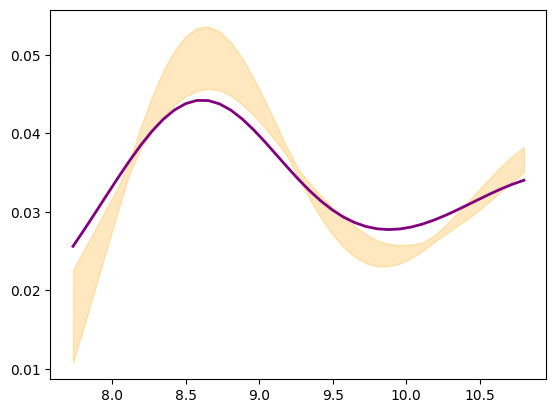

In [25]:
# 用点估计
plt.plot(t_grid, mu_hat_grid, color='purple', linewidth=2, label='Point estimate μ(t)')
# basic CI（与你现在的 mu_lb_basic/mu_ub_basic 配套）
plt.fill_between(t_grid, mu_lb_basic, mu_ub_basic, color='orange', alpha=0.25, label='95% CI (basic)')


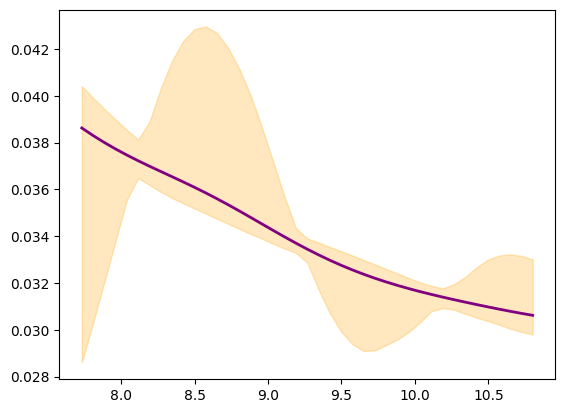

In [26]:
# 保持你的均值曲线
plt.plot(t_grid, mu_boot_mean, color='purple', linewidth=2, label='Bootstrap mean μ(t)')
# 改用百分位区间，围绕 bootstrap 分布本身
plt.fill_between(t_grid, mu_lb_pct, mu_ub_pct, color='orange', alpha=0.25, label='95% CI (percentile)')


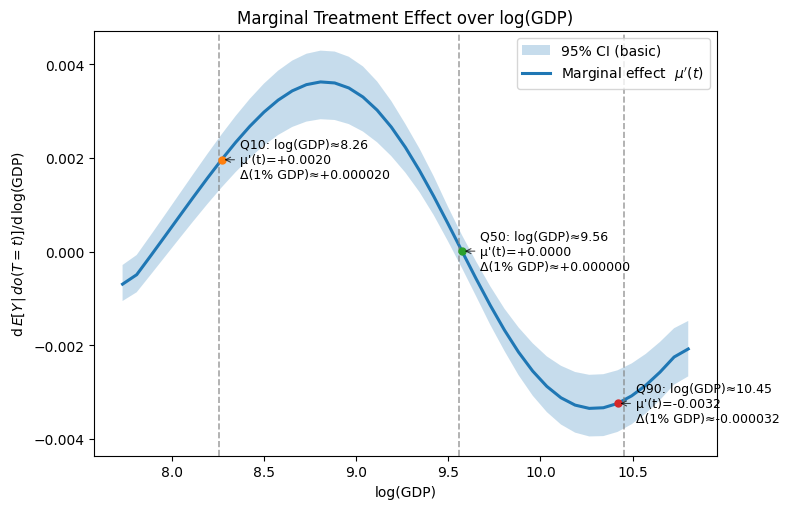

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 若当前作用域里没有该函数，请保留；已有则可删掉 ----
def numerical_derivative(x, y):
    """在不均匀网格上对 y(x) 做数值微分，返回与 y 等长的一阶导数。"""
    dydx = np.empty_like(y)
    dydx[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])  # 中心差分
    dydx[0]  = (y[1] - y[0]) / (x[1] - x[0])          # 前向
    dydx[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])      # 后向
    return dydx

# ============ 1) 由 bootstrap 的 mu(t) 推出 μ'(t) 的自助分布 ============
# mu_boot: shape = (B, len(t_grid))，来自你前面的 parametric bootstrap
# 计算每条自助曲线的导数，得到 me_boot (B × G)
me_boot = np.vstack([numerical_derivative(t_grid, mu_b) for mu_b in mu_boot])

# 点估计的导数（你前面已经有：marginal_effect_log）
me_hat = marginal_effect_log

# 采用 basic 区间（对偏差有修正），也可改成百分位区间
alpha = 0.05
q_lo = np.quantile(me_boot, alpha/2, axis=0)
q_hi = np.quantile(me_boot, 1 - alpha/2, axis=0)
me_lb_basic = 2*me_hat - q_hi
me_ub_basic = 2*me_hat - q_lo

# ============ 2) 计算 Q10/Q50/Q90 并取其在网格上的最近点 ============
q10, q50, q90 = np.quantile(T, [0.10, 0.50, 0.90])  # T 是 log(GDP) 的样本向量
idx10 = np.argmin(np.abs(t_grid - q10))
idx50 = np.argmin(np.abs(t_grid - q50))
idx90 = np.argmin(np.abs(t_grid - q90))

# 便于在标注里显示“1% GDP 变动”的边际效应（= dμ/dlogGDP × 0.01）
to_pct = lambda v: 0.01 * v

# ============ 3) 画图 ============
plt.figure(figsize=(8,5.2))

# 95% 置信带
plt.fill_between(t_grid, me_lb_basic, me_ub_basic, alpha=0.25, label='95% CI (basic)')

# 边际效应点估计曲线
plt.plot(t_grid, me_hat, linewidth=2.2, label=r"Marginal effect  $\mu'(t)$")

# Q10 / Q50 / Q90 的竖线与点位标记
for q, idx, name in [(q10, idx10, 'Q10'), (q50, idx50, 'Q50'), (q90, idx90, 'Q90')]:
    plt.axvline(q, ls='--', lw=1.2, alpha=0.7, color='gray')
    plt.plot([t_grid[idx]], [me_hat[idx]], 'o', ms=5)
    # 文本标注：显示 μ'(t) 与 1% 变动对应的 ΔE[Y]
    txt = (f"{name}: log(GDP)≈{q:.2f}\n"
           f"μ'(t)={me_hat[idx]:+.4f}\n"
           f"Δ(1% GDP)≈{to_pct(me_hat[idx]):+,.6f}")
    # 适度偏移，避免和线重叠
    plt.annotate(txt,
                 xy=(t_grid[idx], me_hat[idx]),
                 xytext=(t_grid[idx]+0.1, me_hat[idx]),
                 textcoords='data',
                 va='center', fontsize=9,
                 arrowprops=dict(arrowstyle='->', lw=0.8, alpha=0.7))

plt.xlabel('log(GDP)')
plt.ylabel(r"$\mathrm{d}\,E[Y\,|\,do(T=t)] / \mathrm{d}\,\log(\mathrm{GDP})$")
plt.title("Marginal Treatment Effect over log(GDP)")
plt.legend()
plt.tight_layout()
plt.show()


关键点（DRF 与边际效应；log尺度 & 1% 变动）：
  t≈Q10:  mu(t)=0.0107,  dmu/dlogGDP=0.007995,  (Δ1%)≈0.000080
  t≈Q50:  mu(t)=0.0384,  dmu/dlogGDP=-0.014003,  (Δ1%)≈-0.000140
  t≈Q90:  mu(t)=0.0079,  dmu/dlogGDP=-0.014038,  (Δ1%)≈-0.000140
Parametric Bootstrap 进行中（T|X 正态 + 二阶段 logit 生成）...
Parametric Bootstrap 完成。


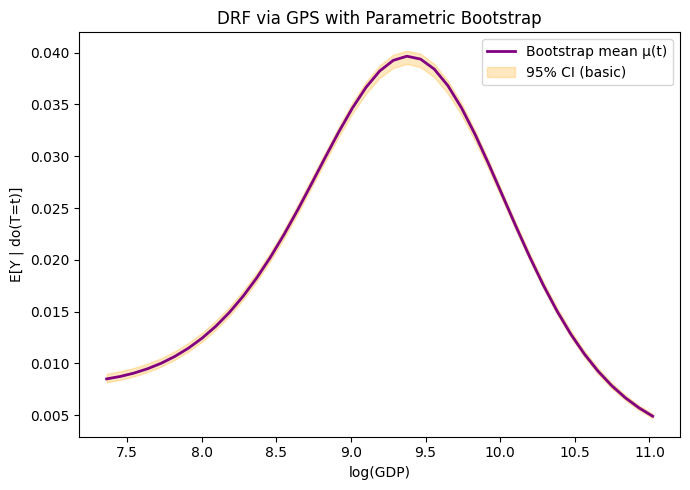

In [10]:
# ============================================
# 连续处理：log(GDP) 的剂量-反应函数 & 边际处理效应（GPS 方法）
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from scipy.stats import norm


# ======= 配置区（按需修改）========
df = sample.copy()                       # <- 你的数据框
T_raw_col = 'gdp_after_move'            # 连续处理（原始 GDP）
USE_LOG_T = True                         # ★ 使用 log(GDP) 作为处理 这里使用GDP log值
Y_col = 'is_beijing'                     # 结果（0/1）
X_cols = ['high_school','junior_college','bachelor','rural','income_total_m']  # 协变量

POLY_DEGREE = 2                          # 第二阶段多项式阶数：2 或 3 常用
GRID_Q_LOW, GRID_Q_HIGH = 0.05, 0.95     # 在 T 的 5%~95% 分位区间上评估
N_GRID = 41                              # t 网格点数量
BOOTSTRAP_B = 100                        # bootstrap 次数（先小后大）
RANDOM_STATE = 42                        # 随机数种子
# =================================

# ---- 预处理：构造 T（log 变换），清理数据 ----
df = df.copy()
# 仅对正的 GDP 取对数；若存在 0/负值，可选择剔除或加常数后取对数（谨慎）
df = df[pd.to_numeric(df[T_raw_col], errors='coerce') > 0].copy()
df[T_raw_col] = pd.to_numeric(df[T_raw_col], errors='coerce')

if USE_LOG_T:
    df = df.assign(T_proc=np.log(df[T_raw_col]))
    T_label = 'log(GDP)'
else:
    df = df.assign(T_proc=df[T_raw_col].astype(float))
    T_label = 'GDP'

keep_cols = [Y_col, 'T_proc'] + X_cols
df = df.dropna(subset=keep_cols).copy()

# 数值化协变量并缺失填 0（稳妥）
for c in X_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

Y = df[Y_col].astype(int).values
T = df['T_proc'].astype(float).values
X = df[X_cols].values

# ---- 标准化 X，用于第一阶段线性回归 ----
scaler_X = StandardScaler()
X_std = scaler_X.fit_transform(X)

# ---- 第一阶段：T|X ~ Normal(mu(X), sigma^2) ----
mu_model = LinearRegression()
mu_model.fit(X_std, T)
mu_hat = mu_model.predict(X_std)
sigma_hat = np.std(T - mu_hat, ddof=X_std.shape[1] + 1)
sigma_hat = max(sigma_hat, 1e-6)  # 防止极小 sigma

# ---- GPS：r(T|X)=phi((T - mu)/sigma)/sigma ----
gps = norm.pdf((T - mu_hat) / sigma_hat) / sigma_hat
gps = np.clip(gps, 1e-12, None)
df['gps'] = gps

# ---- 第二阶段：Y ~ poly(T, gps)（含交互），用逻辑回归拟合 E[Y|T,gps] ----
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=True)
Z = poly.fit_transform(np.c_[T, gps])

outcome_model = LogisticRegression(max_iter=5000)
outcome_model.fit(Z, Y)

# ---- 构造函数：给定 t，计算 mu(t) = E_i[ m(t, r(t,X_i)) ] ----
def compute_gps_at_t(t, mu_x, sigma):
    r = norm.pdf((t - mu_x) / sigma) / sigma
    return np.clip(r, 1e-12, None)

def predict_mu_over_grid(t_grid):
    mu_of_t = []
    mu_x_all = mu_model.predict(X_std)  # mu(X_i) 只拟合一次
    for t in t_grid:
        gps_t = compute_gps_at_t(t, mu_x_all, sigma_hat)
        Z_t = poly.transform(np.c_[np.full_like(gps_t, t, dtype=float), gps_t])
        m_ti = outcome_model.predict_proba(Z_t)[:, 1]
        mu_of_t.append(m_ti.mean())
    return np.array(mu_of_t)

def numerical_derivative(x, y):
    dydx = np.empty_like(y)
    dydx[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])  # 中心差分
    dydx[0]  = (y[1] - y[0]) / (x[1] - x[0])          # 前向
    dydx[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])      # 后向
    return dydx

# ---- t 网格 & 主估计（t 现在是 log(GDP) 尺度）----
t_low, t_high = np.quantile(T, GRID_Q_LOW), np.quantile(T, GRID_Q_HIGH)
t_grid = np.linspace(t_low, t_high, N_GRID)

mu_hat_grid = predict_mu_over_grid(t_grid)
marginal_effect_log = numerical_derivative(t_grid, mu_hat_grid)   # d mu / d log(GDP)
marginal_effect_pct = 0.01 * marginal_effect_log                  # 1% GDP 变化的边际效应

print("关键点（DRF 与边际效应；log尺度 & 1% 变动）：")
for p in [0.1, 0.5, 0.9]:
    tp = np.quantile(T, p)
    idx = np.argmin(np.abs(t_grid - tp))
    print(f"  t≈Q{int(p*100)}:  mu(t)={mu_hat_grid[idx]:.4f},  "
          f"dmu/dlogGDP={marginal_effect_log[idx]:.6f},  "
          f"(Δ1%)≈{marginal_effect_pct[idx]:.6f}")

# ========= Parametric Bootstrap for DRF (pointwise CIs) =========
from numpy.random import default_rng
rng = default_rng(RANDOM_STATE)

def simulate_one_bootstrap(mu_model, sigma_hat, outcome_model, poly, X_std, X, t_grid):
    """
    用已拟合的一/二阶段模型参数，模拟一个自助样本 (T_b, Y_b)，
    然后在该样本上重跑整条管线，返回该样本的 mu_b(t)。
    """
    n = X.shape[0]

    # —— 1) 按 T|X 的正态工作模型模拟 T_b
    mu_x = mu_model.predict(X_std)
    T_b = rng.normal(loc=mu_x, scale=sigma_hat, size=n)

    # —— 2) 根据二阶段 outcome_model 计算 p_b 并模拟 Y_b
    gps_b = norm.pdf((T_b - mu_x) / sigma_hat) / sigma_hat
    gps_b = np.clip(gps_b, 1e-12, None)
    Z_b_sim = poly.transform(np.c_[T_b, gps_b])
    p_b = outcome_model.predict_proba(Z_b_sim)[:, 1]
    Y_b = rng.binomial(1, np.clip(p_b, 1e-8, 1-1e-8), size=n).astype(int)

    # —— 3) 在 (Y_b, T_b, X) 上重拟合一/二阶段
    mu_m = LinearRegression().fit(X_std, T_b)
    mu_hat_b = mu_m.predict(X_std)
    sigma_b = np.std(T_b - mu_hat_b, ddof=X_std.shape[1] + 1)
    sigma_b = max(sigma_b, 1e-6)

    gps_refit = norm.pdf((T_b - mu_hat_b) / sigma_b) / sigma_b
    gps_refit = np.clip(gps_refit, 1e-12, None)

    Z_refit = poly.fit_transform(np.c_[T_b, gps_refit])
    out_m = LogisticRegression(max_iter=5000)
    out_m.fit(Z_refit, Y_b)

    # —— 4) 计算该样本上的 mu_b(t)
    mu_x_all_b = mu_m.predict(X_std)
    mu_vec = []
    for t in t_grid:
        gps_t_b = norm.pdf((t - mu_x_all_b) / sigma_b) / sigma_b
        gps_t_b = np.clip(gps_t_b, 1e-12, None)
        Z_t_b = poly.transform(np.c_[np.full_like(gps_t_b, t, dtype=float), gps_t_b])
        m_ti_b = out_m.predict_proba(Z_t_b)[:, 1]
        mu_vec.append(m_ti_b.mean())
    return np.array(mu_vec)

def parametric_bootstrap_drf(n_boot=BOOTSTRAP_B):
    mu_boot = np.zeros((n_boot, len(t_grid)))
    for b in range(n_boot):
        mu_boot[b] = simulate_one_bootstrap(mu_model, sigma_hat, outcome_model, poly, X_std, X, t_grid)
    return mu_boot

print("Parametric Bootstrap 进行中（T|X 正态 + 二阶段 logit 生成）...")
mu_boot = parametric_bootstrap_drf(n_boot=BOOTSTRAP_B)
print("Parametric Bootstrap 完成。")

# —— 点位置信区间：percentile 与 basic（推荐 basic）
alpha = 0.05
q_lo = np.quantile(mu_boot, alpha/2, axis=0)
q_hi = np.quantile(mu_boot, 1 - alpha/2, axis=0)

# 百分位区间
mu_lb_pct, mu_ub_pct = q_lo, q_hi
# basic 区间（对偏差有修正）
mu_lb_basic = 2*mu_hat_grid - q_hi
mu_ub_basic = 2*mu_hat_grid - q_lo

# —— 画图：一条代表性 bootstrap 曲线 + 点估计/或替代 + CI
# 代表性曲线：平均 或 中位数（二选一，默认平均）
mu_boot_mean = mu_boot.mean(axis=0)          # 平均曲线
# mu_boot_med = np.median(mu_boot, axis=0)   # 或者用中位数曲线

plt.figure(figsize=(7,5))
# 只画一条 bootstrap 代表曲线（可与点估计二选一显示）
plt.plot(t_grid, mu_boot_mean, color='purple', linewidth=2, label='Bootstrap mean μ(t)')
# plt.plot(t_grid, mu_boot_med, color='purple', linewidth=2, label='Bootstrap median μ(t)')

# 若仍想对比你的点估计，可保留；若不需要就注释掉下一行
#plt.plot(t_grid, mu_hat_grid, color='blue', linestyle='--', linewidth=1.6, label='Point estimate μ(t)')

# 置信带（basic 或 percentile 二选一；这里用 basic）
plt.fill_between(t_grid, mu_lb_basic, mu_ub_basic, color='orange', alpha=0.25, label='95% CI (basic)')
# 若想改用百分位区间，注释上一行，启用下一行：
# plt.fill_between(t_grid, mu_lb_pct, mu_ub_pct, color='skyblue', alpha=0.20, label='95% CI (percentile)')

plt.xlabel(T_label)
plt.ylabel('E[Y | do(T=t)]')
plt.title('DRF via GPS with Parametric Bootstrap')
plt.legend()
plt.tight_layout()
plt.show()

 

关键点（DRF 与边际效应；log尺度 & 1% 变动）：
  t≈Q10:  mu(t)=0.0397,  dmu/dlogGDP=0.026877,  (Δ1%)≈0.000269
  t≈Q50:  mu(t)=0.0287,  dmu/dlogGDP=-0.014761,  (Δ1%)≈-0.000148
  t≈Q90:  mu(t)=0.0305,  dmu/dlogGDP=0.013660,  (Δ1%)≈0.000137
Parametric Bootstrap 进行中（T|X 正态 + 二阶段 logit 生成）...
Parametric Bootstrap 完成。


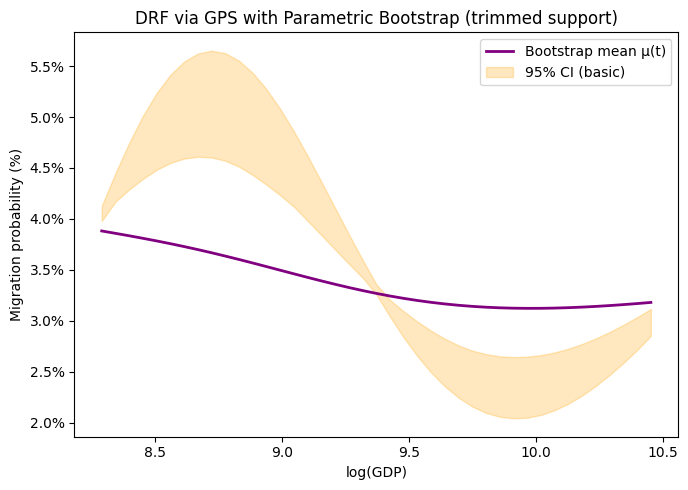

In [35]:
# ============================================
# 连续处理：log(GDP) 的剂量-反应函数 & 边际处理效应（GPS 方法）
# —— 修正：overlap trimming + 固定特征映射 + 稳健 sigma —— 
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from scipy.stats import norm
from numpy.random import default_rng
from matplotlib.ticker import FuncFormatter

# ======= 配置区（按需修改）========
df = sample.copy()
T_raw_col = 'gdp_before_move'
USE_LOG_T = True
df['is_migrated_BJSH'] = ((df['is_beijing'] == 1) | (df['is_shanghai'] == 1)).astype(int)

# —— 这里按你的需要设定 Y —— 
Y_col = 'is_shanghai'        # 你现在在看上海
# Y_col = 'is_migrated_BJSH' # 如需合并北京/上海，改用这一行

X_cols = ['high_school','junior_college','bachelor','rural','income_total_m']

POLY_DEGREE = 2
GRID_Q_LOW, GRID_Q_HIGH = 0.10, 0.90      # // 修改点：只在 10%~90% 画图（更稳的中段）
N_GRID = 41
BOOTSTRAP_B = 100
RANDOM_STATE = 42
TRIM_Q = 0.01                              # // 修改点：GPS 裁剪阈值（1%）

# =================================
df = df.copy()
df = df[pd.to_numeric(df[T_raw_col], errors='coerce') > 0].copy()
df[T_raw_col] = pd.to_numeric(df[T_raw_col], errors='coerce')

if USE_LOG_T:
    df = df.assign(T_proc=np.log(df[T_raw_col]))
    T_label = 'log(GDP)'
else:
    df = df.assign(T_proc=df[T_raw_col].astype(float))
    T_label = 'GDP'

keep_cols = [Y_col, 'T_proc'] + X_cols
df = df.dropna(subset=keep_cols).copy()

for c in X_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

Y_full = df[Y_col].astype(int).values
T_full = df['T_proc'].astype(float).values
X_full = df[X_cols].values

# ---- 标准化 X，用于第一阶段线性回归 ----
scaler_X = StandardScaler()
X_std_full = scaler_X.fit_transform(X_full)

# ---- 第一阶段：T|X ~ Normal(mu(X), sigma^2) ----
mu_model_full = LinearRegression()
mu_model_full.fit(X_std_full, T_full)
mu_hat_full = mu_model_full.predict(X_std_full)

# // 修改点：sigma 用 ddof=1，更稳；后续仅用于 pdf 归一化
sigma_hat_full = np.std(T_full - mu_hat_full, ddof=1)
sigma_hat_full = max(sigma_hat_full, 1e-6)

# ---- 初始 GPS，并做 overlap trimming（公共支撑）----
gps_full = norm.pdf((T_full - mu_hat_full)/sigma_hat_full) / sigma_hat_full
gps_full = np.clip(gps_full, 1e-12, None)

lo, hi = np.quantile(gps_full, [TRIM_Q, 1-TRIM_Q])
mask = (gps_full >= lo) & (gps_full <= hi)

Y = Y_full[mask]
T = T_full[mask]
X = X_full[mask]
X_std = X_std_full[mask]

# —— 在裁剪后的样本上重估第一阶段 —— 
mu_model = LinearRegression().fit(X_std, T)
mu_hat = mu_model.predict(X_std)
sigma_hat = np.std(T - mu_hat, ddof=1)     # // 修改点
sigma_hat = max(sigma_hat, 1e-6)

gps = norm.pdf((T - mu_hat)/sigma_hat) / sigma_hat
gps = np.clip(gps, 1e-12, None)

# ---- 第二阶段：固定特征映射（只 fit 一次），后续 bootstrap 仅 transform ----
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=True)
Z = poly.fit_transform(np.c_[T, gps])

# // 修改点：logit 不加惩罚（或 C 很大）
try:
    outcome_model = LogisticRegression(max_iter=5000, penalty=None)
except Exception:
    outcome_model = LogisticRegression(max_iter=5000, C=1e6)  # 兼容老版本
outcome_model.fit(Z, Y)

def compute_gps_at_t(t, mu_x, sigma):
    r = norm.pdf((t - mu_x) / sigma) / sigma
    return np.clip(r, 1e-12, None)

def predict_mu_over_grid(t_grid, mu_model, sigma_hat, X_std, outcome_model, poly):
    mu_of_t = []
    mu_x_all = mu_model.predict(X_std)
    for t in t_grid:
        gps_t = compute_gps_at_t(t, mu_x_all, sigma_hat)
        Z_t = poly.transform(np.c_[np.full_like(gps_t, t, dtype=float), gps_t])  # // 修改点：transform
        m_ti = outcome_model.predict_proba(Z_t)[:, 1]
        mu_of_t.append(m_ti.mean())
    return np.array(mu_of_t)

def numerical_derivative(x, y):
    dydx = np.empty_like(y)
    dydx[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])
    dydx[0]  = (y[1] - y[0]) / (x[1] - x[0])
    dydx[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])
    return dydx

# ---- t 网格（仅用中段分位区间）----
t_low, t_high = np.quantile(T, GRID_Q_LOW), np.quantile(T, GRID_Q_HIGH)
t_grid = np.linspace(t_low, t_high, N_GRID)

mu_hat_grid = predict_mu_over_grid(
    t_grid, mu_model, sigma_hat, X_std, outcome_model, poly
)
marginal_effect_log = numerical_derivative(t_grid, mu_hat_grid)
marginal_effect_pct = 0.01 * marginal_effect_log

print("关键点（DRF 与边际效应；log尺度 & 1% 变动）：")
for p in [0.1, 0.5, 0.9]:
    tp = np.quantile(T, p)
    idx = np.argmin(np.abs(t_grid - tp))
    print(f"  t≈Q{int(p*100)}:  mu(t)={mu_hat_grid[idx]:.4f},  "
          f"dmu/dlogGDP={marginal_effect_log[idx]:.6f},  "
          f"(Δ1%)≈{marginal_effect_pct[idx]:.6f}")

# ========= Parametric Bootstrap for DRF (pointwise CIs) =========
rng = default_rng(RANDOM_STATE)

def simulate_one_bootstrap(mu_model, sigma_hat, outcome_model, poly, X_std, X, t_grid):
    n = X_std.shape[0]

    # 1) 按工作模型生成 T_b
    mu_x = mu_model.predict(X_std)
    T_b = rng.normal(loc=mu_x, scale=sigma_hat, size=n)

    # 2) 用“固定的” poly 和 outcome_model 生成 p_b，再抽样 Y_b
    gps_b = norm.pdf((T_b - mu_x) / sigma_hat) / sigma_hat
    gps_b = np.clip(gps_b, 1e-12, None)
    Z_b_sim = poly.transform(np.c_[T_b, gps_b])   # // 修改点：只 transform
    p_b = outcome_model.predict_proba(Z_b_sim)[:, 1]
    Y_b = rng.binomial(1, np.clip(p_b, 1e-8, 1-1e-8), size=n).astype(int)

    # 3) 在 (Y_b, T_b, X_std) 上重估一/二阶段（poly 仍然用原 poly.transform）
    mu_m = LinearRegression().fit(X_std, T_b)
    mu_hat_b = mu_m.predict(X_std)
    sigma_b = np.std(T_b - mu_hat_b, ddof=1)
    sigma_b = max(sigma_b, 1e-6)

    gps_refit = norm.pdf((T_b - mu_hat_b) / sigma_b) / sigma_b
    gps_refit = np.clip(gps_refit, 1e-12, None)

    Z_refit = poly.transform(np.c_[T_b, gps_refit])  # // 修改点：transform
    try:
        out_m = LogisticRegression(max_iter=5000, penalty=None)
    except Exception:
        out_m = LogisticRegression(max_iter=5000, C=1e6)
    out_m.fit(Z_refit, Y_b)

    # 4) 计算该样本上的 mu_b(t)
    mu_x_all_b = mu_m.predict(X_std)
    mu_vec = []
    for t in t_grid:
        gps_t_b = norm.pdf((t - mu_x_all_b) / sigma_b) / sigma_b
        gps_t_b = np.clip(gps_t_b, 1e-12, None)
        Z_t_b = poly.transform(np.c_[np.full_like(gps_t_b, t, dtype=float), gps_t_b])
        m_ti_b = out_m.predict_proba(Z_t_b)[:, 1]
        mu_vec.append(m_ti_b.mean())
    return np.array(mu_vec)

def parametric_bootstrap_drf(n_boot=BOOTSTRAP_B):
    mu_boot = np.zeros((n_boot, len(t_grid)))
    for b in range(n_boot):
        mu_boot[b] = simulate_one_bootstrap(mu_model, sigma_hat, outcome_model, poly, X_std, X, t_grid)
    return mu_boot

print("Parametric Bootstrap 进行中（T|X 正态 + 二阶段 logit 生成）...")
mu_boot = parametric_bootstrap_drf(n_boot=BOOTSTRAP_B)
print("Parametric Bootstrap 完成。")

# —— 点位置信区间：percentile 与 basic（推荐 basic）
alpha = 0.05
q_lo = np.quantile(mu_boot, alpha/2, axis=0)
q_hi = np.quantile(mu_boot, 1 - alpha/2, axis=0)

mu_lb_pct, mu_ub_pct = q_lo, q_hi
mu_lb_basic = 2*mu_hat_grid - q_hi
mu_ub_basic = 2*mu_hat_grid - q_lo

# —— 可视化（百分数刻度）
to_pct = lambda a: 100.0 * a
mu_boot_mean = mu_boot.mean(axis=0)

plt.figure(figsize=(7,5))
plt.plot(t_grid, to_pct(mu_boot_mean), color='purple', linewidth=2, label='Bootstrap mean μ(t)')
plt.fill_between(t_grid, to_pct(mu_lb_basic), to_pct(mu_ub_basic), color='orange', alpha=0.25, label='95% CI (basic)')
plt.xlabel(T_label)
plt.ylabel('Migration probability (%)')
plt.title('DRF via GPS with Parametric Bootstrap (trimmed support)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:.1f}%'))
plt.legend()
plt.tight_layout()
plt.show()


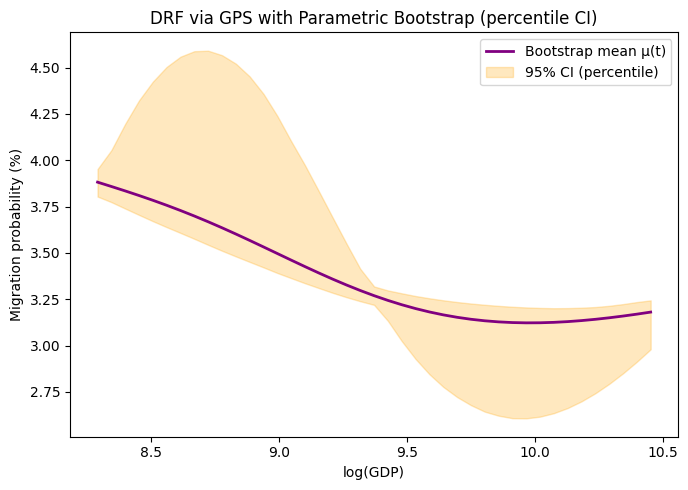

In [31]:
# —— CI 用百分位区间（与紫色曲线同源）
alpha = 0.05
q_lo = np.quantile(mu_boot, alpha/2, axis=0)
q_hi = np.quantile(mu_boot, 1 - alpha/2, axis=0)

mu_boot_mean = mu_boot.mean(axis=0)

plt.figure(figsize=(7,5))
plt.plot(t_grid, 100*mu_boot_mean, color='purple', lw=2, label='Bootstrap mean μ(t)')
plt.fill_between(t_grid, 100*q_lo, 100*q_hi, color='orange', alpha=0.25, label='95% CI (percentile)')
plt.xlabel(T_label)
plt.ylabel('Migration probability (%)')
plt.title('DRF via GPS with Parametric Bootstrap (percentile CI)')
plt.legend(); plt.tight_layout(); plt.show()


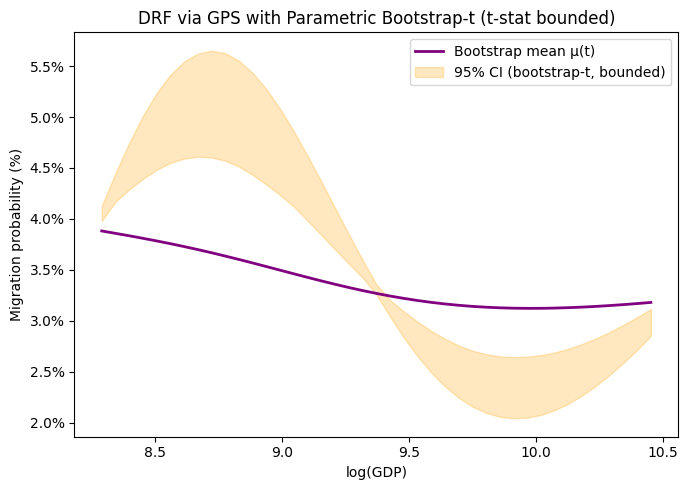

In [37]:
# ========= 用 bootstrap-t + t-stat bounding 构造区间 =========
alpha = 0.05
T_BOUND_Q = (alpha/2, 1 - alpha/2)   # 2.5% 与 97.5% 分位，作为默认 bounding

# 1) 点位标准误：直接用 bootstrap 样本的标准差（点位）
se_hat = np.std(mu_boot, axis=0, ddof=1)
# 避免除零
se_hat = np.where(se_hat < 1e-12, 1e-12, se_hat)

# 2) 学生化 t 统计：每个 b、每个 t 的 t 值
t_boot = (mu_boot - mu_hat_grid[None, :]) / se_hat[None, :]

# 3) 对 t 做 winsor/bounding：按分位数裁掉极端（而不是对估计做裁剪）
t_lo = np.quantile(t_boot, T_BOUND_Q[0], axis=0)
t_hi = np.quantile(t_boot, T_BOUND_Q[1], axis=0)

# 4) bootstrap-t 区间（逐点）
mu_lb_t = mu_hat_grid - t_hi * se_hat
mu_ub_t = mu_hat_grid - t_lo * se_hat

# ========= 可视化（百分比纵轴；只画一条代表性曲线 + t-CI） =========
to_pct = lambda a: 100.0 * a
mu_boot_mean = mu_boot.mean(axis=0)

plt.figure(figsize=(7,5))
plt.plot(t_grid, to_pct(mu_boot_mean), color='purple', linewidth=2,
         label='Bootstrap mean μ(t)')
plt.fill_between(t_grid, to_pct(mu_lb_t), to_pct(mu_ub_t),
                 color='orange', alpha=0.25, label='95% CI (bootstrap-t, bounded)')
plt.xlabel(T_label)
plt.ylabel('Migration probability (%)')
plt.title('DRF via GPS with Parametric Bootstrap-t (t-stat bounded)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:.1f}%'))
plt.legend()
plt.tight_layout()
plt.show()


Parametric Bootstrap running ...
Parametric Bootstrap done.
Overlap diag -> min_cnt=21165 | reach_cnt[min,med,max]=(1058285, 1058286, 1058287) | max_w[min,med,max]=(0.0000, 0.0000, 0.0000) | valid grid points: 41/41


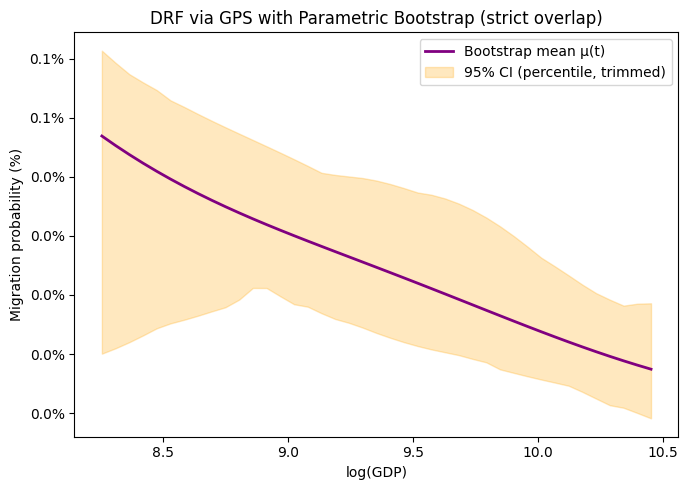

In [33]:
# ============================================
# DRF for continuous treatment log(GDP) via GPS
# with strict overlap trimming & parametric bootstrap (percentile CI)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from scipy.stats import norm
from numpy.random import default_rng

# ======= 配置区（按需修改）========
df = sample.copy()                       # <- 你的数据框
T_raw_col = 'gdp_before_move'            # 连续处理（原始 GDP）
USE_LOG_T = True                         # 使用 log(GDP) 作为处理
# 可二选一：Y_col = 'is_shanghai'  或使用合并 BJ/SH
df['is_migrated_BJSH'] = ((df['is_beijing']==1) | (df['is_shanghai']==1)).astype(int)
Y_col = 'is_shanghai'                    # 结果（0/1）
X_cols = ['high_school','junior_college','bachelor','rural','income_total_m']  # 协变量

POLY_DEGREE = 2                          # 第二阶段多项式阶数
GRID_Q_LOW, GRID_Q_HIGH = 0.10, 0.90     # 收紧评估区间，避免端点外推
N_GRID = 41                              # t 网格点数量
BOOTSTRAP_B = 100                        # bootstrap 次数（可加大到 300-500）
RANDOM_STATE = 42                        # 随机数种子

# —— 严格支撑裁剪阈值（可微调）
Z0 = 2.0                                 # 可达邻域半径（z-score）
MIN_FRAC = 0.02                          # 邻域内样本至少占比
MIN_ABS = 1200                           # 邻域内样本至少绝对数
MAX_W = 0.01                             # 单个观测最大权重上限（防止单点主导）

# —— 二阶段正则强度（C越小正则越强）
LOGIT_C = 0.5

# —— 自助法里二次抽样次数（降低蒙特卡洛噪声）
M_Y = 5
# ============================================

# ---------- 预处理 ----------
df = df.copy()
df = df[pd.to_numeric(df[T_raw_col], errors='coerce') > 0].copy()
df[T_raw_col] = pd.to_numeric(df[T_raw_col], errors='coerce')

if USE_LOG_T:
    df = df.assign(T_proc=np.log(df[T_raw_col]))
    T_label = 'log(GDP)'
else:
    df = df.assign(T_proc=df[T_raw_col].astype(float))
    T_label = 'GDP'

keep_cols = [Y_col, 'T_proc'] + X_cols
df = df.dropna(subset=keep_cols).copy()

for c in X_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

Y = df[Y_col].astype(int).values
T = df['T_proc'].astype(float).values
X = df[X_cols].values

# ---------- 标准化 X ----------
scaler_X = StandardScaler()
X_std = scaler_X.fit_transform(X)

# ---------- 第一阶段：T|X ~ Normal(mu(X), sigma^2) ----------
mu_model = LinearRegression().fit(X_std, T)
mu_hat = mu_model.predict(X_std)
# ddof 使用 p+1（略保守）
sigma_hat = np.std(T - mu_hat, ddof=X_std.shape[1] + 1)
sigma_hat = max(sigma_hat, 1e-6)

# ---------- GPS ----------
gps = norm.pdf((T - mu_hat) / sigma_hat) / sigma_hat
gps = np.clip(gps, 1e-12, None)

# ---------- 第二阶段：Y ~ poly(T, gps) + 交互（Logit + L2） ----------
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=True)
Z = poly.fit_transform(np.c_[T, gps])
outcome_model = LogisticRegression(penalty='l2', C=LOGIT_C, solver='lbfgs', max_iter=5000)
outcome_model.fit(Z, Y)

# ---------- 预测 μ(t) ----------
def compute_gps_at_t(t, mu_x, sigma):
    r = norm.pdf((t - mu_x) / sigma) / sigma
    return np.clip(r, 1e-12, None)

def predict_mu_over_grid(t_grid):
    mu_of_t = []
    mu_x_all = mu_model.predict(X_std)
    for t in t_grid:
        gps_t = compute_gps_at_t(t, mu_x_all, sigma_hat)
        Z_t = poly.transform(np.c_[np.full_like(gps_t, t, dtype=float), gps_t])
        p_ti = outcome_model.predict_proba(Z_t)[:, 1]
        mu_of_t.append(p_ti.mean())
    return np.array(mu_of_t)

# ---------- 数值导数（若后续需要边际效应） ----------
def numerical_derivative(x, y):
    dydx = np.empty_like(y)
    dydx[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])
    dydx[0]  = (y[1] - y[0]) / (x[1] - x[0])
    dydx[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])
    return dydx

# ---------- t 网格 ----------
t_low, t_high = np.quantile(T, GRID_Q_LOW), np.quantile(T, GRID_Q_HIGH)
t_grid = np.linspace(t_low, t_high, N_GRID)

mu_hat_grid = predict_mu_over_grid(t_grid)

# ---------- Parametric Bootstrap（带降噪） ----------
rng = default_rng(RANDOM_STATE)

def simulate_one_bootstrap(mu_model, sigma_hat, outcome_model, poly, X_std, X, t_grid):
    n = X.shape[0]
    mu_x = mu_model.predict(X_std)
    # 1) 模拟 T_b ~ N(mu_x, sigma_hat^2)
    T_b = rng.normal(loc=mu_x, scale=sigma_hat, size=n)
    # 2) 用二阶段生成 p_b，再多次伯努利取均值阈值化，降低噪声
    gps_b = norm.pdf((T_b - mu_x) / sigma_hat) / sigma_hat
    gps_b = np.clip(gps_b, 1e-12, None)
    Z_b_sim = poly.transform(np.c_[T_b, gps_b])
    p_b = outcome_model.predict_proba(Z_b_sim)[:, 1]
    p_b = np.clip(p_b, 1e-8, 1 - 1e-8)
    Yb_stack = [rng.binomial(1, p_b).astype(int) for _ in range(M_Y)]
    Y_b = (np.mean(Yb_stack, axis=0) >= 0.5).astype(int)

    # 3) 在 (Y_b, T_b, X) 上重拟合一/二阶段
    mu_m = LinearRegression().fit(X_std, T_b)
    mu_hat_b = mu_m.predict(X_std)
    sigma_b = np.std(T_b - mu_hat_b, ddof=X_std.shape[1] + 1)
    sigma_b = max(sigma_b, 1e-6)

    gps_refit = norm.pdf((T_b - mu_hat_b) / sigma_b) / sigma_b
    gps_refit = np.clip(gps_refit, 1e-12, None)
    Z_refit = poly.fit_transform(np.c_[T_b, gps_refit])

    out_m = LogisticRegression(penalty='l2', C=LOGIT_C, solver='lbfgs', max_iter=5000)
    out_m.fit(Z_refit, Y_b)

    # 4) 计算 μ_b(t)
    mu_x_all_b = mu_m.predict(X_std)
    mu_vec = []
    for t in t_grid:
        gps_t_b = norm.pdf((t - mu_x_all_b) / sigma_b) / sigma_b
        gps_t_b = np.clip(gps_t_b, 1e-12, None)
        Z_t_b = poly.transform(np.c_[np.full_like(gps_t_b, t, dtype=float), gps_t_b])
        p_ti_b = out_m.predict_proba(Z_t_b)[:, 1]
        mu_vec.append(p_ti_b.mean())
    return np.array(mu_vec)

def parametric_bootstrap_drf(n_boot=BOOTSTRAP_B):
    mu_boot = np.zeros((n_boot, len(t_grid)))
    for b in range(n_boot):
        mu_boot[b] = simulate_one_bootstrap(mu_model, sigma_hat, outcome_model, poly, X_std, X, t_grid)
    return mu_boot

print("Parametric Bootstrap running ...")
mu_boot = parametric_bootstrap_drf(n_boot=BOOTSTRAP_B)
print("Parametric Bootstrap done.")

# ---------- 百分位置信区间（后面要裁剪支撑） ----------
alpha = 0.05
q_lo = np.quantile(mu_boot, alpha/2, axis=0)
q_hi = np.quantile(mu_boot, 1 - alpha/2, axis=0)

# ---------- 严格重叠性诊断 & 裁剪 ----------
mu_x_all = mu_model.predict(X_std)
# 可达邻域样本计数（|t - mu_i|/sigma <= Z0）
z_mat = np.stack([np.abs((t - mu_x_all) / sigma_hat) for t in t_grid], axis=1)  # n x G
reach_cnt = (z_mat <= Z0).sum(axis=0)

# 权重最大占比（防单点主导）
gps_mat = np.stack([norm.pdf((t - mu_x_all)/sigma_hat)/sigma_hat for t in t_grid], axis=1)
gps_mat = np.clip(gps_mat, 1e-12, None)
w = gps_mat / gps_mat.sum(axis=0, keepdims=True)
max_w = w.max(axis=0)

n = len(Y)
min_cnt = max(int(MIN_FRAC * n), MIN_ABS)
mask = (reach_cnt >= min_cnt) & (max_w <= MAX_W)

# 把无支撑点的区间置 NaN，不绘制
q_lo_trim = q_lo.copy(); q_hi_trim = q_hi.copy()
q_lo_trim[~mask] = np.nan; q_hi_trim[~mask] = np.nan

print(f"Overlap diag -> min_cnt={min_cnt} | "
      f"reach_cnt[min,med,max]=({int(reach_cnt.min())}, {int(np.median(reach_cnt))}, {int(reach_cnt.max())}) | "
      f"max_w[min,med,max]=({max_w.min():.4f}, {np.median(max_w):.4f}, {max_w.max():.4f}) | "
      f'valid grid points: {int(np.isfinite(q_lo_trim).sum())}/{len(t_grid)}')

# ---------- 作图（百分比纵轴） ----------
to_pct = lambda a: 100.0 * a
plt.figure(figsize=(7,5))
plt.plot(t_grid, to_pct(mu_boot.mean(axis=0)), color='purple', lw=2, label='Bootstrap mean μ(t)')
plt.fill_between(t_grid, to_pct(q_lo_trim), to_pct(q_hi_trim),
                 color='orange', alpha=0.25, label='95% CI (percentile, trimmed)')
plt.xlabel(T_label)
plt.ylabel('Migration probability (%)')
plt.title('DRF via GPS with Parametric Bootstrap (strict overlap)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:.1f}%'))
plt.legend()
plt.tight_layout()
plt.show()


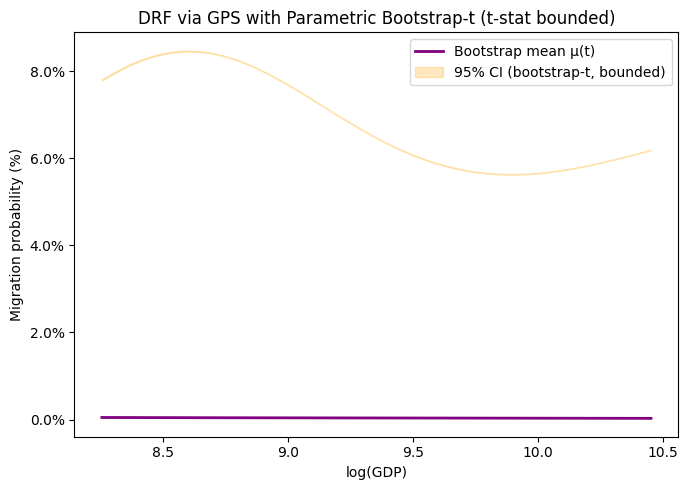

In [34]:
# ========= 用 bootstrap-t + t-stat bounding 构造区间 =========
alpha = 0.05
T_BOUND_Q = (alpha/2, 1 - alpha/2)   # 2.5% 与 97.5% 分位，作为默认 bounding

# 1) 点位标准误：直接用 bootstrap 样本的标准差（点位）
se_hat = np.std(mu_boot, axis=0, ddof=1)
# 避免除零
se_hat = np.where(se_hat < 1e-12, 1e-12, se_hat)

# 2) 学生化 t 统计：每个 b、每个 t 的 t 值
t_boot = (mu_boot - mu_hat_grid[None, :]) / se_hat[None, :]

# 3) 对 t 做 winsor/bounding：按分位数裁掉极端（而不是对估计做裁剪）
t_lo = np.quantile(t_boot, T_BOUND_Q[0], axis=0)
t_hi = np.quantile(t_boot, T_BOUND_Q[1], axis=0)

# 4) bootstrap-t 区间（逐点）
mu_lb_t = mu_hat_grid - t_hi * se_hat
mu_ub_t = mu_hat_grid - t_lo * se_hat

# ========= 可视化（百分比纵轴；只画一条代表性曲线 + t-CI） =========
to_pct = lambda a: 100.0 * a
mu_boot_mean = mu_boot.mean(axis=0)

plt.figure(figsize=(7,5))
plt.plot(t_grid, to_pct(mu_boot_mean), color='purple', linewidth=2,
         label='Bootstrap mean μ(t)')
plt.fill_between(t_grid, to_pct(mu_lb_t), to_pct(mu_ub_t),
                 color='orange', alpha=0.25, label='95% CI (bootstrap-t, bounded)')
plt.xlabel(T_label)
plt.ylabel('Migration probability (%)')
plt.title('DRF via GPS with Parametric Bootstrap-t (t-stat bounded)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:.1f}%'))
plt.legend()
plt.tight_layout()
plt.show()
